# Figure 2: Dual occluder task

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2026-01-14 11:12:34,535::INFO::settings.py::Setting loglevel to INFO
2026-01-14 11:12:34,537::INFO::settings.py::Setting stores to {}
2026-01-14 11:12:34,538::INFO::settings.py::Setting database.misc.schema_prefix to 
2026-01-14 11:12:34,538::INFO::settings.py::Setting database.misc.create_tables to True
2026-01-14 11:12:34,539::INFO::settings.py::Setting enable_python_native_blobs to True
2026-01-14 11:12:34,540::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2026-01-14 11:12:34,543::INFO::settings.py::Setting database.user to celia
2026-01-14 11:12:34,544::INFO::settings.py::Setting database.password to celia_mathislab
2026-01-14 11:12:34,733::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2026-01-14 11:12:34,841::INFO::table.py::could not log event in table ~log
2026-01-14 11:12:35,268::INFO::table.py::could not log event in table ~log
2026-01-14 11:12:35,268::INFO::table.py::could not log event in table ~log
2026-01-14 11:12:35,791::INFO::table.py::could not log event in table ~log
2026-01-14 11:12:35,791::INFO::table.py::could not log event in table ~log
2026-01-14 11:12:35,940::INFO::table.py::could not log event in table ~log
2026-01-14 11:12:35,940::INFO::table.py::could not log event in table ~log
2026-01-14 11:12:36,284::INFO::table.py::could not log event in table ~log
2026-01-14 11:12:36,284::INFO::table.py::could not log event in table ~log
2026-01-14 11:12:36,630::INFO::table.py::could not log event in table ~log
2026-01-14 11:12:36,630::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
from vr4mice.schema.vr4mice import Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanXYTrajectory, MeanVelocities,YBinnedXYTrajectory
from vr4mice.schema.session_metrics import TrialMetrics, SessionMetrics
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM

import statsmodels.api as sm
from statsmodels.formula.api import ols
from vr4mice.analysis.stats import plot_aperture_heatmap, get_multi_performance_p_val

from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")


style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

2026-01-14 11:12:36,817::INFO::table.py::could not log event in table ~log
2026-01-14 11:12:36,817::INFO::table.py::could not log event in table ~log
2026-01-14 11:12:36,960::INFO::table.py::could not log event in table ~log
2026-01-14 11:12:36,960::INFO::table.py::could not log event in table ~log


## Example trajectories (Pheasant_2024-08-15_2)

In [5]:
# Load dataset and box positions
df = DataFrame().get_data(
    key={"dataset": "Pheasant_2024-08-15_2"},
    columns=[
        "dataset",
        "reward",
        "x",
        "y",
        "trial",
        "aperture",
        "iti",
        "trial_left_choice",
        "trial_duration",
        "trial_tortuosity",
        "trial_init_x",
        "trial_init_y"
    ],
)
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

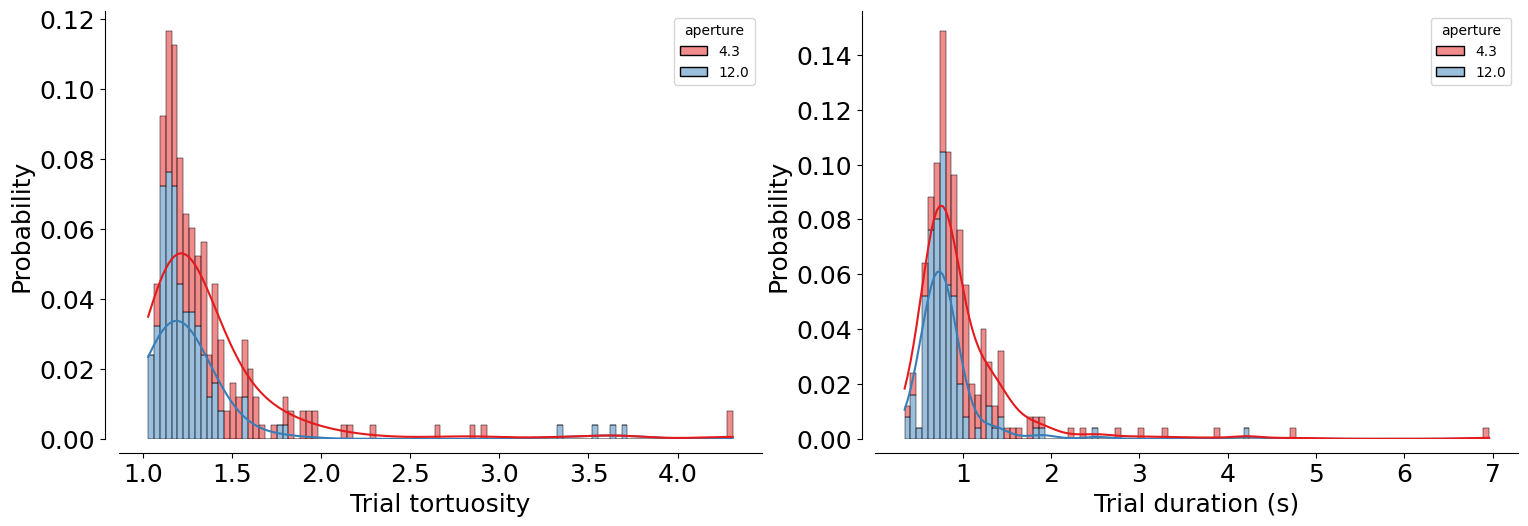

In [6]:
# Tortuosity and duration
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax = plotting.plot_tortuosity_duration_distribution(df, ax=ax, log_scale=False)
fig.tight_layout(pad=0.2)
ax[0].set_xlabel("Trial tortuosity")
ax[1].set_xlabel("Trial duration (s)")

sns.despine(offset=10)

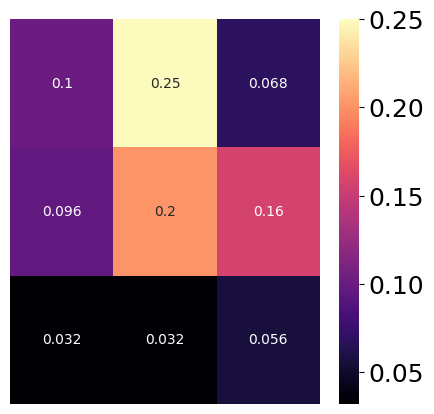

In [7]:
# Averaged initial starting position
fig, ax = plt.subplots(8, 6, figsize=(25, 25))
ax = ax.flatten()

df_init = df

hists = []
for i, session in enumerate(df_init.dataset.unique()):
    hist = plotting.plot_init_position_histogram(
        df_init[df_init.dataset == session],
        box_df,
        ax=ax[i],
        bins=3,
        cmap="magma",
        vmax=40,
        is_density=False,
    )

    number_trials = (
        df_init[df_init.dataset == session].groupby(["trial"]).x.first().count()
    )
    hist = hist / number_trials
    hists.append(hist)

    ax[i].set_title(f"{session}")
# plt.close()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.heatmap(
    np.flip(np.mean(hists, axis=0), axis=1).T,
    cmap="magma",
    annot=(np.flip(np.mean(hists, axis=0), axis=1).T),
    vmax=0.25,
)

ax.set_xticks([])
ax.set_yticks([])

fig.savefig(save_fig_path + "Figure2_example_initial_position_heatmap.svg", dpi=300, bbox_inches="tight", transparent=True)

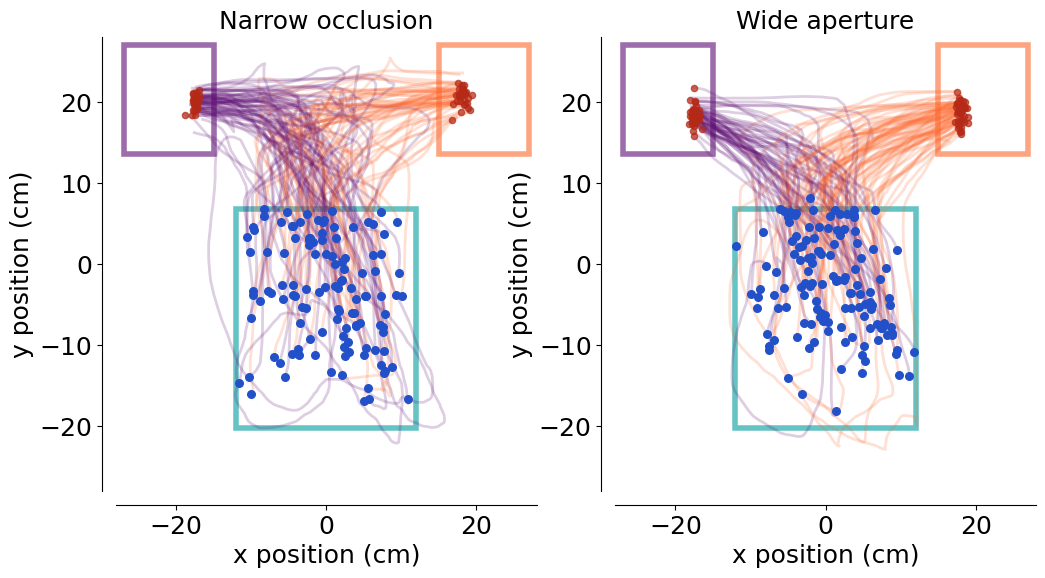

In [8]:
df = df[df.iti == 0.0]
j_shaped = analysis.get_jshaped_trials(df)

ax = plotting.plot_session(
    df=j_shaped,
    box_df=box_df,
    per_aperture=True,
    per_side=True,
)

ax[0].set_title("Narrow occlusion")
ax[1].set_title("Wide aperture")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure2_example_session_trajectory_plot_dual_occluder.svg", transparent=True)

## Combined sessions analysis
Fetching the data:

In [9]:
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])

# Exclude sessions that were not in the list
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df, 
                                                        task_type="dual_occluder",
                                                        return_excluded=False)

# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

In [10]:
mouse_list

array(['Pheasant_2024-08-21_1', 'Pheasant_2024-08-20_1',
       'Pheasant_2024-08-19_1', 'Pheasant_2024-08-16_1',
       'Pheasant_2024-08-15_2', 'Oribi_2024-08-22_1',
       'Oribi_2024-08-21_1', 'Oribi_2024-08-20_1', 'Oribi_2024-08-19_1',
       'Oribi_2024-08-16_1', 'Nightingale_2024-08-14_1',
       'Nightingale_2024-08-13_1', 'Nightingale_2024-08-12_1',
       'Nightingale_2024-08-11_1', 'Nightingale_2024-08-10_1',
       'Lemming_2024-08-13_1', 'Lemming_2024-08-12_1',
       'Lemming_2024-08-11_1', 'Lemming_2024-08-10_1',
       'Kiwi_2024-08-14_1', 'Kiwi_2024-08-13_1', 'Kiwi_2024-08-12_2',
       'Kiwi_2024-08-11_4', 'Kiwi_2024-08-10_2', 'Jacana_2024-08-19_1',
       'Jacana_2024-08-16_1', 'Jacana_2024-08-15_1',
       'Jacana_2024-08-14_1', 'Jacana_2024-08-13_1', 'J731_2024-12-09_1',
       'J731_2024-12-05_1', 'J729_2024-12-10_1', 'J729_2024-12-04_1',
       'J729_2024-12-03_1', 'J729_2024-12-02_1', 'J729_2024-12-01_1',
       'J729_2024-11-30_1', '31728_2025-03-21_1', '31728_

In [11]:
trial_df.groupby("mouse_name").nunique().dataset

mouse_name
31726          4
31728          3
J729           6
J731           2
Jacana         5
Kiwi           5
Lemming        4
Nightingale    5
Oribi          5
Pheasant       5
Name: dataset, dtype: int64

In [12]:
df_init = pd.concat(DataFrame().get_data(
        key={"dataset": mouse},
        columns=[
            "dataset",
            "trial",
            "trial_init_x",
            "trial_init_y",
            "trial_left_choice",
            "aperture"
        ],
    ) for mouse in mouse_list)

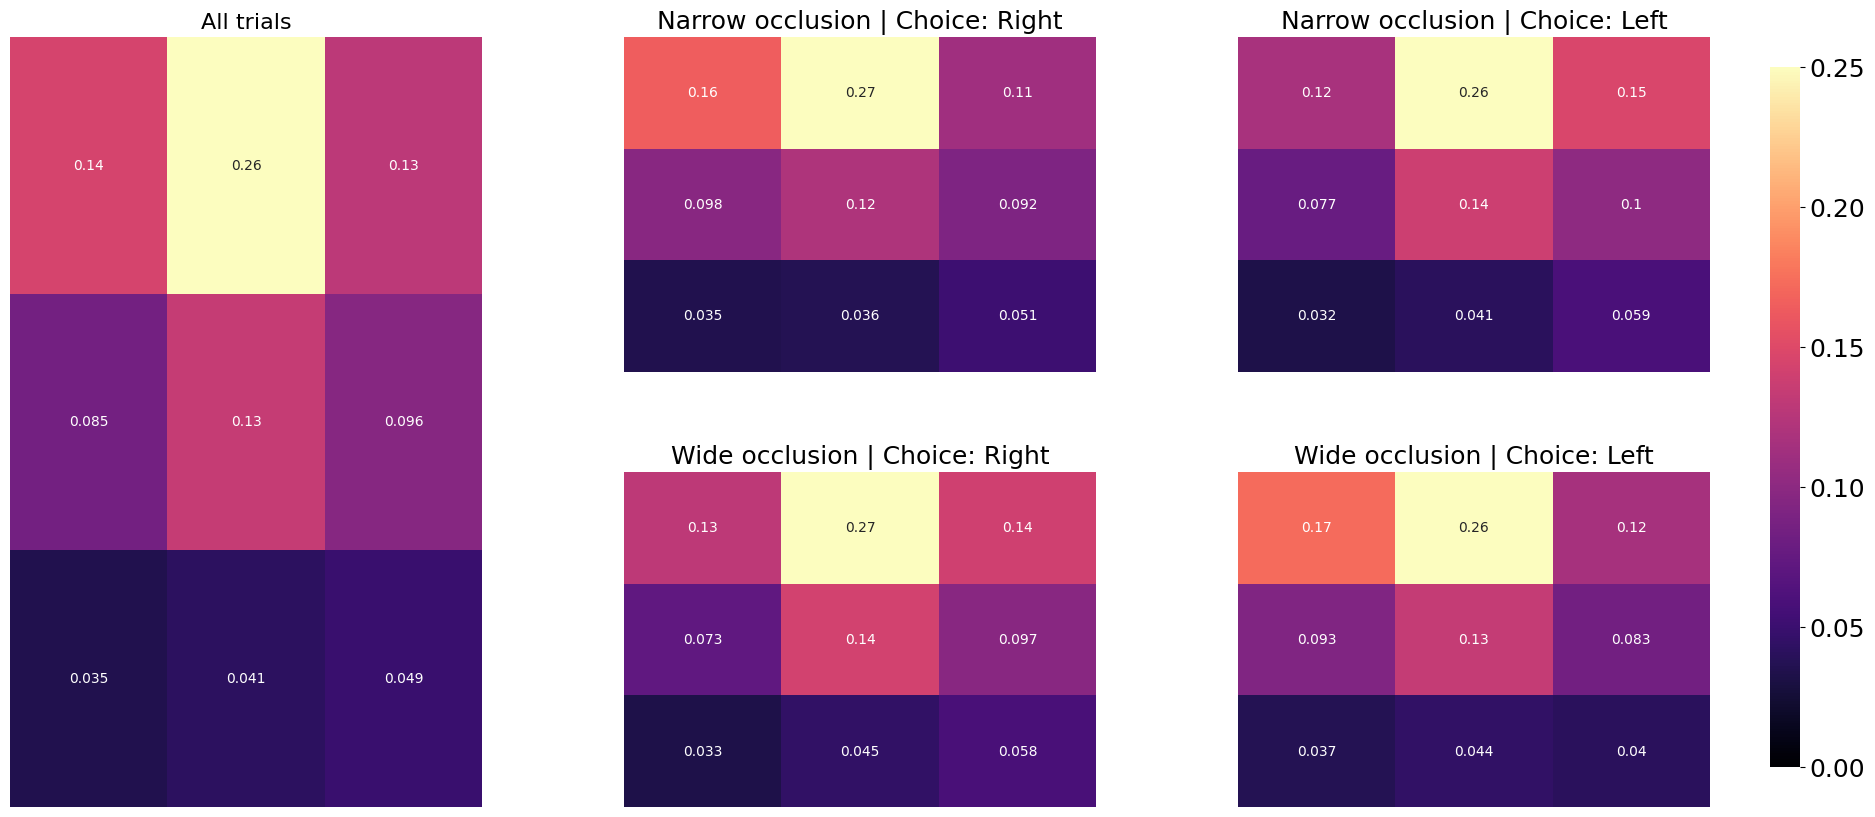

In [13]:
apertures = df_init.aperture.unique()
choices = df_init.trial_left_choice.unique()
hist_dict = {(a, c): [] for a in apertures for c in choices}
all_sessions_hists = []

for session in df_init.dataset.unique():
    session_df = df_init[df_init.dataset == session]
    
    # Calculate Full Histogram for this session
    full_hist = plotting.plot_init_position_histogram(
        session_df, box_df, ax=None, bins=3, is_density=False
    )
    n_total = session_df.groupby("trial").trial_init_x.first().count()
    all_sessions_hists.append(full_hist / n_total)
    
    # Calculate conditioned Histograms for this session
    for ap in apertures:
        for ch in choices:
            subset = session_df[(session_df.aperture == ap) & (session_df.trial_left_choice == ch)]
            if not subset.empty:
                h = plotting.plot_init_position_histogram(
                    subset, box_df, ax=None, bins=3, is_density=False
                )
                n_cond = subset.groupby("trial").trial_init_x.first().count()
                hist_dict[(ap, ch)].append(h / n_cond)

fig = plt.figure(figsize=(20, 10))
ax_full = plt.subplot2grid((2, 3), (0, 0), rowspan=2)
ax_43_0 = plt.subplot2grid((2, 3), (0, 1))
ax_43_1 = plt.subplot2grid((2, 3), (0, 2))
ax_12_0 = plt.subplot2grid((2, 3), (1, 1))
ax_12_1 = plt.subplot2grid((2, 3), (1, 2))

axes_map = {(4.3, 0): ax_43_0, (4.3, 1): ax_43_1, (12, 0): ax_12_0, (12, 1): ax_12_1}
VMAX = 0.25
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])

full_mean = np.mean(all_sessions_hists, axis=0)
sns.heatmap(np.flip(full_mean, axis=1).T, cmap="magma", annot=True, 
            vmax=VMAX, vmin=0, ax=ax_full, cbar=False)
ax_full.set_title("All trials", fontsize=16)

for (ap, ch), ax in axes_map.items():
    if hist_dict[(ap, ch)]:
        cond_mean = np.mean(hist_dict[(ap, ch)], axis=0)
        sns.heatmap(np.flip(cond_mean, axis=1).T, cmap="magma", annot=True, 
                    vmax=VMAX, vmin=0, ax=ax, cbar=True, cbar_ax=cbar_ax)
    
    ax.set_title(f"{'Wide' if ap > 6 else 'Narrow'} occlusion | Choice: {'Left' if ch==1 else 'Right'}")

# Formatting cleanup
for ax in [ax_full, ax_43_0, ax_43_1, ax_12_0, ax_12_1]:
    ax.set_xticks([])
    ax.set_yticks([])

plt.subplots_adjust(left=0.05, right=0.9, wspace=0.3, hspace=0.3)
fig.savefig(save_fig_path + "figure2_initial_position_heatmaps.svg", dpi=300, bbox_inches="tight", transparent=True)

In [14]:
trial_df["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

2026-01-14 11:18:20,426::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:20,426::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:20,440::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:20,440::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:20,523::INFO::category.py::Using categorical un

4.3 vs chance 0: t=53.10, p=0.000
12.0 vs chance 0: t=85.13, p=0.000
12.0-4.3: TtestResult(statistic=5.81236275608486, pvalue=6.850432270264985e-07, df=43)
              mean       sem
aperture                    
12.0      0.862708  0.010135
4.3       0.758126  0.014278


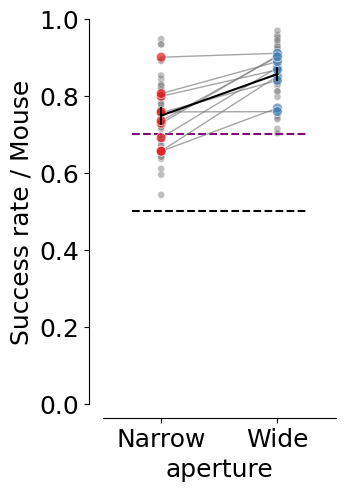

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.hlines(
    0.7,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="purple",
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)
plt.ylim(0, 1.0)
plt.xlim(-0.5, 1.5)
ax.set_ylabel("Success rate / Mouse")
ax.set_xlabel("aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "Figure2_trial_reward.svg", transparent=True)

2026-01-14 11:18:20,817::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:20,817::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:20,824::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:20,824::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:20,861::INFO::category.py::Using categorical un

4.3 vs chance 0: t=53.10, p=0.000
12.0 vs chance 0: t=85.13, p=0.000
12.0-4.3: TtestResult(statistic=7.176569859891019, pvalue=7.148814431559152e-09, df=43)
              mean       sem
aperture                    
12.0      0.862708  0.010135
4.3       0.758126  0.014278


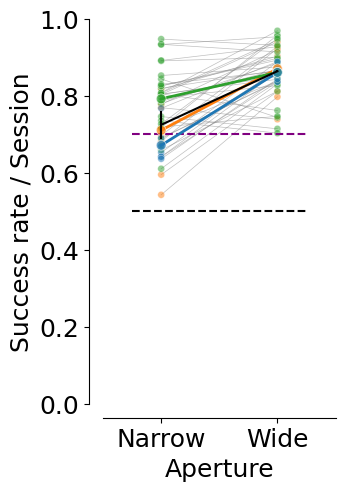

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_lab=True,
)
ax.hlines(
    0.7,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="purple",
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)
ax.set_ylim(0, 1.0)
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel("Success rate / Session")
ax.set_xlabel("Aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])

sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "Figure2_trial_reward_per_lab.svg", transparent=True)


2026-01-14 11:18:21,351::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:21,351::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:21,359::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:21,359::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:21,391::INFO::category.py::Using categorical un

wide aperture mean:  0.5036019322606283 std:  0.03954979212420795
narrow aperture mean:  0.49639806773937173 std:  0.03954979212420796


TtestResult(statistic=0.597207926999779, pvalue=0.553500499897813, df=43)

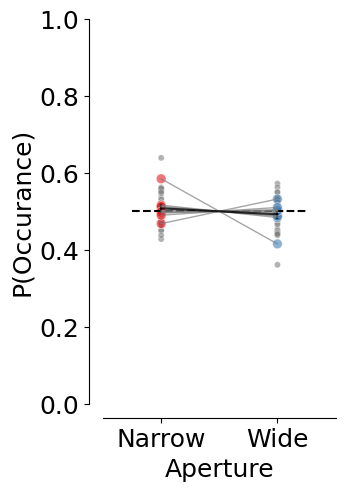

In [17]:
# Occurance of the different conditions
counts = (
    trial_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    trial_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts["aperture"] = counts.aperture.astype("str")

fig, ax = plt.subplots(1, 1, figsize=(3, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    ax=ax,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=plotting.colors_aperture,
    alpha=0.6,
    s=50,
    zorder=2,
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    ax=ax,
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
)

ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

plt.ylim(0, 1)
plt.xlim(-0.5, 1.5)
plt.xticks([0, 1], ["Narrow", "Wide"])

plt.xlabel("Aperture")
plt.ylabel("P(Occurance)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "figure2_dual_occluder_trial_number.svg", transparent=True)

counts = counts.pivot(index="dataset", columns=["aperture"], values=["probability"])
print(
    "wide aperture mean: ",
    np.mean(np.array(counts["probability"]["12.0"])),
    "std: ",
    np.std(np.array(counts["probability"]["12.0"])),
)
print(
    "narrow aperture mean: ",
    np.mean(np.array(counts["probability"]["4.3"])),
    "std: ",
    np.std(np.array(counts["probability"]["4.3"])),
)
ttest_rel(
    np.array(counts["probability"]["12.0"]), np.array(counts["probability"]["4.3"])
)

In [18]:
from vr4mice.analysis import plotting

2026-01-14 11:18:21,689::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:21,689::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:21,701::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:21,701::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:21,729::INFO::category.py::Using categorical un

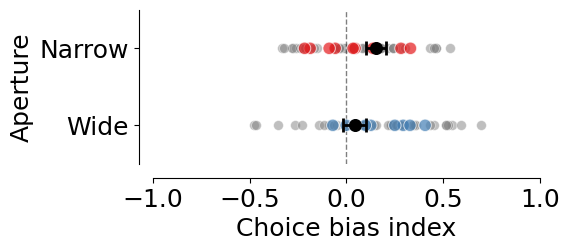

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    plot_bias=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2][::-1],
    per_mouse=True,
)

ax.set_ylim(-0.5, 1.5)
ax.set_ylabel("Aperture")
ax.set_yticks([0, 1], ["Wide", "Narrow"])
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Choice bias index")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure2_dual_occluder_choice_bias.svg", transparent=True)

2026-01-14 11:18:21,952::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:21,952::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:21,963::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:21,963::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:21,992::INFO::category.py::Using categorical un

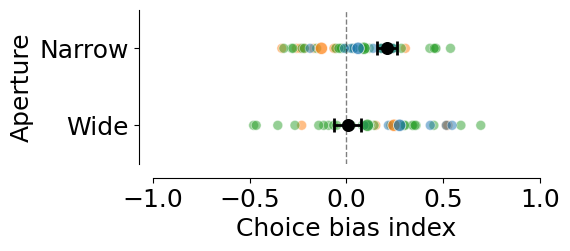

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    plot_bias=True,
    per_lab=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
)

ax.set_ylim(-0.5, 1.5)
ax.set_ylabel("Aperture")
ax.set_yticks([0, 1], ["Wide", "Narrow"])
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Choice bias index")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure2_dual_occluder_choice_bias_lab.svg", transparent=True)

In [21]:
# Stickiness of the decision
trial_df["trial_history"] = trial_df.groupby(
                    ["dataset"]
                )["trial_left_choice"].transform(lambda x: x.shift(1))

trial_df["decision_stickiness"] = (
    (trial_df['trial_left_choice'] == trial_df['trial_history'])
    .groupby([trial_df['dataset'], trial_df['trial']])
    .transform('mean')
)

2026-01-14 11:18:22,288::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:22,288::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:22,294::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:22,294::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:22,327::INFO::category.py::Using categorical un

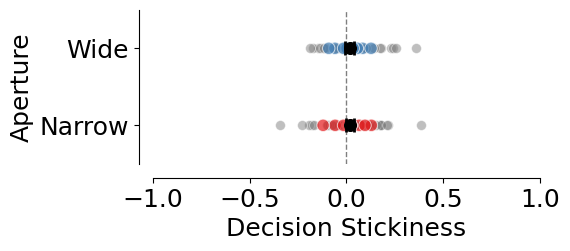

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="decision_stickiness",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
    plot_bias=True,
)

ax.set_ylim(-0.5, 1.5)
ax.set_yticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Aperture")
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Decision Stickiness")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure2_dual_occluder_decision_stickiness.svg", transparent=True)

2026-01-14 11:18:22,658::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:22,658::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:22,663::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:22,663::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:22,739::INFO::category.py::Using categorical un

1.4439540393990793
12.0-4.3: TtestResult(statistic=-7.078955728656972, pvalue=9.89161622318722e-09, df=43)


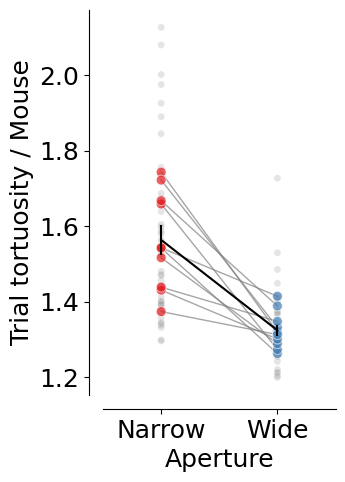

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = (
    trial_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .trial_tortuosity.mean()
)

counts["count"] = counts["trial_tortuosity"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

print(counts.groupby(["mouse_name", "aperture"]).mean().trial_tortuosity.mean())

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_ylabel("Trial tortuosity / Mouse")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Aperture")

plt.legend([], [], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["trial_tortuosity"],
                counts[counts["aperture"] == j]["trial_tortuosity"],
            )
            print(f"{i}-{j}: {stat}")

plt.savefig(save_fig_path + "figure2_dual_occluder_trial_tortuosity.svg", transparent=True)

In [24]:
stats_test = pd.DataFrame(
    zip(
        counts.groupby("aperture")["count"].mean(),
        counts.groupby("aperture")["count"].sem(),
    ),
    columns=["mean", "sem"],
    index=counts.groupby("aperture")["count"].mean().index,
)
for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = ttest_rel(
                counts[counts["aperture"] == i]["count"],
                counts[counts["aperture"] == j]["count"],
            )
            print(f"{i}-{j}: {stat}")
print(stat)

12.0-4.3: TtestResult(statistic=-7.078955728656972, pvalue=9.89161622318722e-09, df=43)
TtestResult(statistic=-7.078955728656972, pvalue=9.89161622318722e-09, df=43)


2026-01-14 11:18:23,208::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:23,208::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:23,217::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:23,217::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:18:23,340::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=4.086999247495281, pvalue=0.00018737967976443473, df=43)


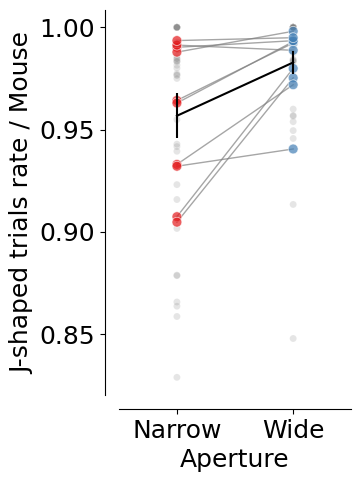

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = (
    trial_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .trial_jshaped.mean()
)

counts["count"] = counts["trial_jshaped"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_ylabel("J-shaped trials rate / Mouse")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Aperture")

plt.legend([], [], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["trial_jshaped"],
                counts[counts["aperture"] == j]["trial_jshaped"],
            )
            print(f"{i}-{j}: {stat}")

plt.savefig(save_fig_path + "figure2_dual_occluder_trial_jshaped.svg", transparent=True)

In [26]:
stats_test = pd.DataFrame(
    zip(
        counts.groupby("aperture")["count"].mean(),
        counts.groupby("aperture")["count"].sem(),
    ),
    columns=["mean", "sem"],
    index=counts.groupby("aperture")["count"].mean().index,
)
for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = ttest_rel(
                counts[counts["aperture"] == i]["count"],
                counts[counts["aperture"] == j]["count"],
            )
            print(f"{i}-{j}: {stat}")
print(stats_test)

12.0-4.3: TtestResult(statistic=4.086999247495281, pvalue=0.00018737967976443473, df=43)
              mean       sem
aperture                    
12.0      0.983841  0.004300
4.3       0.961303  0.007212


## Trajectory analysis

In [27]:
xy_df = []
for m in mouse_list:
    xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0]))
xy_df = pd.concat(xy_df)
xy_df ["mouse_name"] = xy_df.dataset.str.split("_").str [0]

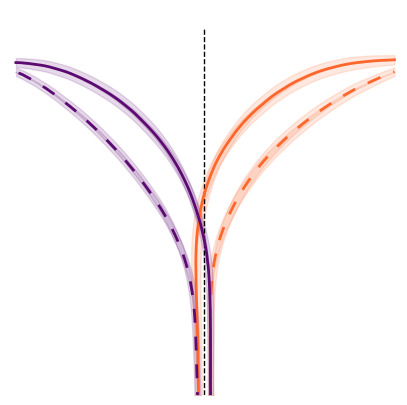

In [28]:
# Mean and error by session
mean_session = analysis.mean_xy_trajectory(xy_df,
                                         index_columns=[
                                             "dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"
                                         ])

# Mean and error by aperture and choice
mean_group = analysis.mean_xy_trajectory(mean_session, 
                                         index_columns=[
                                             "aperture",  "trial_left_choice", "trial_length"
                                         ])

# Plot the mean trajectories
plotting.plot_mean_xy_trajectory(mean_group, cmap=plotting.colors_choice[::-1], color_by="choice", style_by="aperture")
plt.savefig(save_fig_path + "figure_2_dual_occluder_mean_xy_trajectories.svg", transparent=True)
plt.savefig(save_fig_path + "figure_2_dual_occluder_mean_xy_trajectories.png", transparent=True, dpi=300)

In [29]:
# Mean and error by mouse
mean_mouse = analysis.mean_xy_trajectory(xy_df, 
                                         index_columns= [
                                             "mouse_name", "aperture", "trial_left_choice", "trial_length"
                                         ])

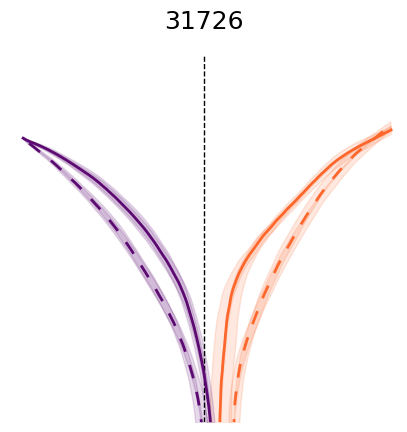

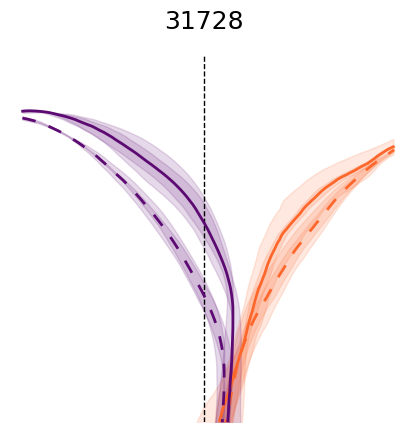

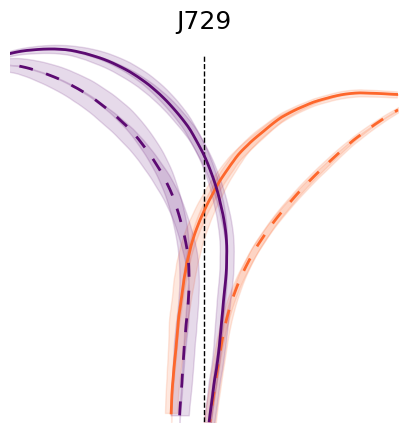

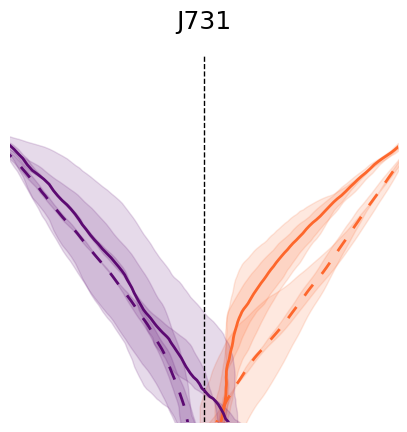

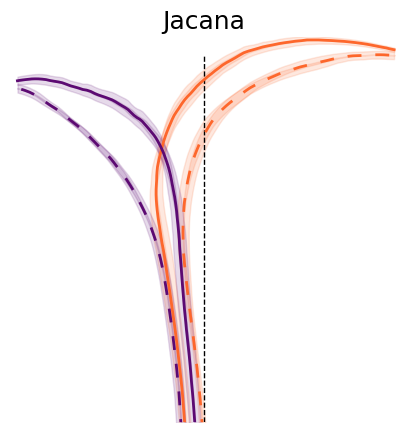

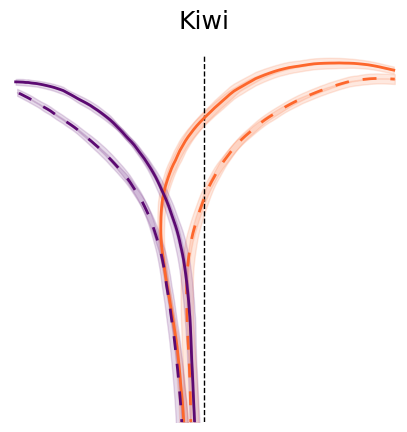

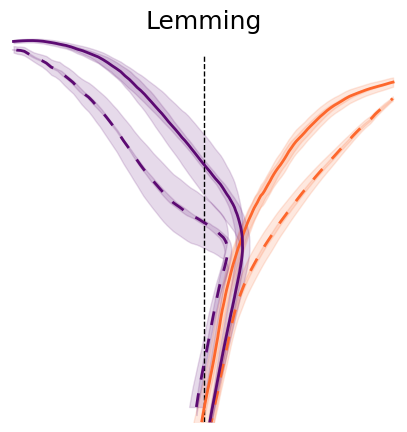

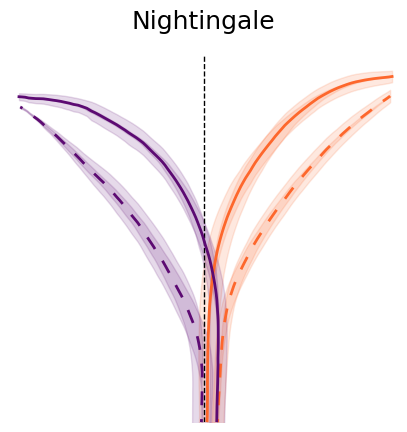

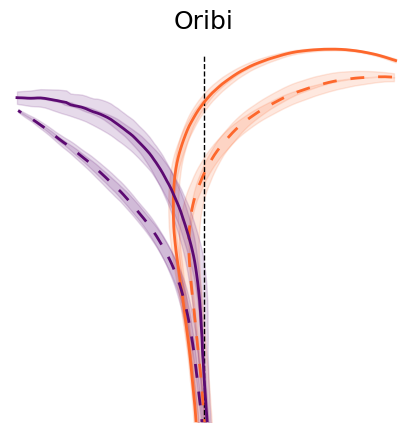

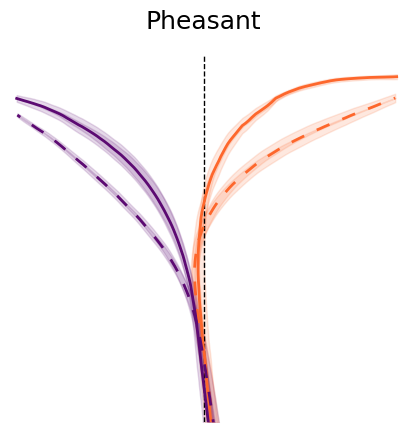

In [30]:
for m in mean_mouse.mouse_name.unique():
    plotting.plot_mean_xy_trajectory(mean_mouse[mean_mouse.mouse_name == m], 
                                     cmap=plotting.colors_choice[::-1], color_by="choice", style_by="aperture")
    plt.title(m)
    plt.savefig(save_fig_path + f"figure2_dual_occluders_trajectories_time_{m}.svg", transparent=True)
    plt.savefig(save_fig_path + f"figure2_dual_occluders_trajectories_time_{m}.png", transparent=True, dpi=300)

In [31]:
# currently takes 1.1 mins
y_binned_df = []
for m in mouse_list:
    try:
        #print(m)
        y_binned_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "x", "y", "flip_one_side", "trial_left_choice", as_dict=True)[0]))
    except Exception as err:
        print(err)
y_binned_df = pd.concat(y_binned_df)

In [32]:
y_binned_df ["mouse_name"] = y_binned_df.dataset.str.split("_").str [0]
y_binned_df ["x_flipped"] = y_binned_df.x * y_binned_df.flip_one_side
data = utils.create_bins(y_binned_df)
y_binned_df = analysis.mean_xy_trajectory(data, index_columns= ["dataset", "mouse_name", "aperture", "bin_centers"], values=["x_flipped", "y"])

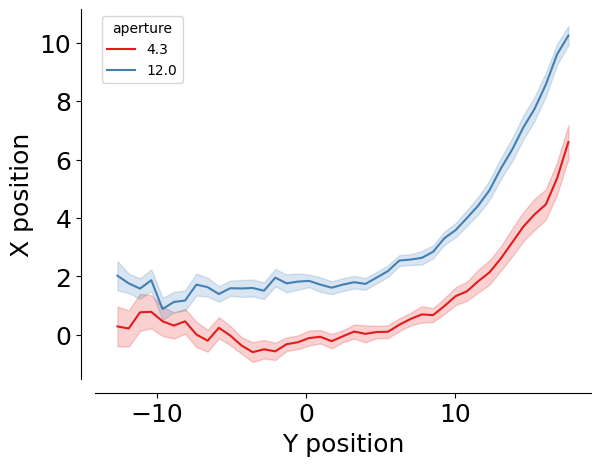

In [33]:
stats_binned = y_binned_df[(y_binned_df.bin_centers > -15) & (y_binned_df.bin_centers < 18)]

sns.lineplot(data = stats_binned, x="bin_centers", y="x_flipped", hue="aperture", 
             palette= plotting.colors_aperture, errorbar="se")
plt.xlabel("Y position")
plt.ylabel("X position")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure2_dual_occluder_mean_xy_trajectory.svg", transparent=True)

In [34]:
stats_binned = y_binned_df[(y_binned_df.bin_centers > -15) & (y_binned_df.bin_centers < 18)]
print(
    AnovaRM(
        data=stats_binned,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

                        Anova
                     F Value  Num DF   Den DF  Pr > F
-----------------------------------------------------
aperture             70.8456  1.0000   43.0000 0.0000
bin_centers          91.7688 40.0000 1720.0000 0.0000
aperture:bin_centers  6.8298 40.0000 1720.0000 0.0000



In [35]:
p_values = []
for i in stats_binned.bin_centers.unique():
    section = stats_binned [stats_binned.bin_centers == i]
    t = ttest_rel(
        section[section.aperture == section.aperture.unique()[0]].x_flipped,
        section[section.aperture == section.aperture.unique()[1]].x_flipped,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

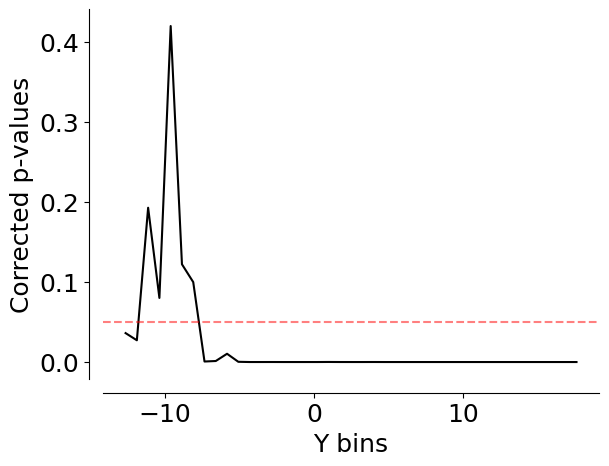

In [36]:
sns.lineplot(data=p_value_df, x="segment", y="p_value_corr", c="black")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)
plt.xlabel("Y bins")
plt.ylabel("Corrected p-values")
#plt.ylim(0,0.08)

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure2_dual_occluder_position_p_values.svg", transparent=True)

In [37]:
velocity_df = []
for m in mouse_list:
    print(m)
    velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
velocity_df = pd.concat(velocity_df)

Pheasant_2024-08-21_1
Pheasant_2024-08-20_1
Pheasant_2024-08-19_1
Pheasant_2024-08-16_1
Pheasant_2024-08-15_2
Oribi_2024-08-22_1
Oribi_2024-08-21_1
Oribi_2024-08-20_1
Oribi_2024-08-19_1
Oribi_2024-08-16_1
Nightingale_2024-08-14_1
Nightingale_2024-08-13_1
Nightingale_2024-08-12_1
Nightingale_2024-08-11_1
Nightingale_2024-08-10_1
Lemming_2024-08-13_1
Lemming_2024-08-12_1
Lemming_2024-08-11_1
Lemming_2024-08-10_1
Kiwi_2024-08-14_1
Kiwi_2024-08-13_1
Kiwi_2024-08-12_2
Kiwi_2024-08-11_4
Kiwi_2024-08-10_2
Jacana_2024-08-19_1
Jacana_2024-08-16_1
Jacana_2024-08-15_1
Jacana_2024-08-14_1
Jacana_2024-08-13_1
J731_2024-12-09_1
J731_2024-12-05_1
J729_2024-12-10_1
J729_2024-12-04_1
J729_2024-12-03_1
J729_2024-12-02_1
J729_2024-12-01_1
J729_2024-11-30_1
31728_2025-03-21_1
31728_2025-03-20_1
31728_2025-03-07_1
31726_2025-03-21_1
31726_2025-03-20_1
31726_2025-03-19_1
31726_2025-03-18_1


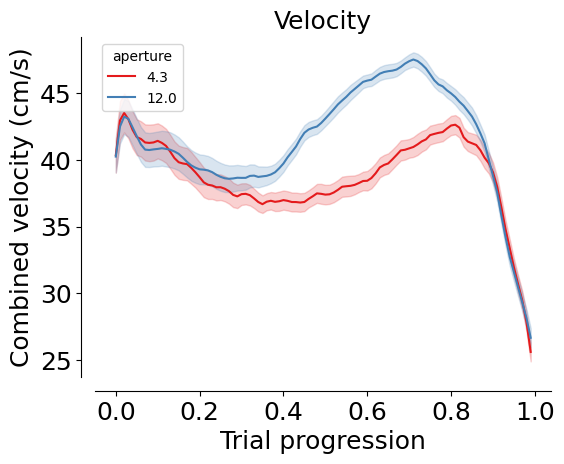

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = ax

sns.lineplot(
    data=velocity_df,
    x="trial_length",
    y="velocity",
    palette=(
        plotting.colors_aperture[:2]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_aperture[:2]
    ),
    hue="aperture",
    errorbar="se",
    ax=ax,
)
ax.set_title(f"Velocity")
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure2_mean_velocity.svg", transparent=True)

In [39]:
print(
    AnovaRM(
        data=velocity_df,
        depvar="velocity",
        subject="dataset",
        within=["aperture", "trial_length"],
    ).fit()
)

                        Anova
                      F Value  Num DF   Den DF  Pr > F
------------------------------------------------------
aperture              60.2403  1.0000   43.0000 0.0000
trial_length          44.5172 99.0000 4257.0000 0.0000
aperture:trial_length 36.8483 99.0000 4257.0000 0.0000



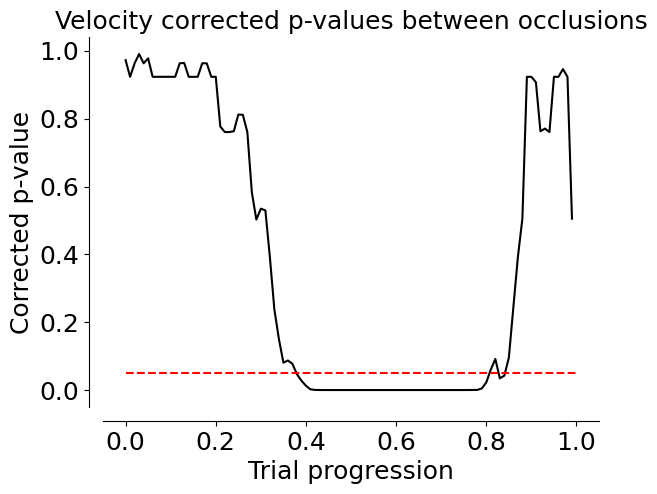

In [40]:
p_values = []
for i in velocity_df.trial_length.unique():
    section = velocity_df[velocity_df.trial_length == i]
    t = ttest_ind(
        section[section.aperture == section.aperture.unique()[0]].velocity,
        section[section.aperture == section.aperture.unique()[1]].velocity,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(0.05, xmin=0, xmax=1, color="red", linestyle="dashed")

plt.xlabel("Trial progression")
plt.ylabel("Corrected p-value")
plt.title("Velocity corrected p-values between occlusions")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure2_velocity_pvalue.svg", transparent=True)

In [41]:
# TODO This fecth call is a little slow, maybe we should add an optimal p table
optimal_df = []
for m in mouse_list:
    print(m)
    optimal_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "trial", "aperture", "optimal_p", as_dict=True)[0]))
optimal_df = pd.concat(optimal_df)

# Create list of included datasets
mouse_list = optimal_df.dataset.unique()
optimal_df["mouse_name"] = optimal_df.dataset.str.split("_").str [0]

optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "trial", "aperture"], as_index=False).mean()
optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "aperture"], as_index=False).mean()

Pheasant_2024-08-21_1
Pheasant_2024-08-20_1
Pheasant_2024-08-19_1
Pheasant_2024-08-16_1
Pheasant_2024-08-15_2
Oribi_2024-08-22_1
Oribi_2024-08-21_1
Oribi_2024-08-20_1
Oribi_2024-08-19_1
Oribi_2024-08-16_1
Nightingale_2024-08-14_1
Nightingale_2024-08-13_1
Nightingale_2024-08-12_1
Nightingale_2024-08-11_1
Nightingale_2024-08-10_1
Lemming_2024-08-13_1
Lemming_2024-08-12_1
Lemming_2024-08-11_1
Lemming_2024-08-10_1
Kiwi_2024-08-14_1
Kiwi_2024-08-13_1
Kiwi_2024-08-12_2
Kiwi_2024-08-11_4
Kiwi_2024-08-10_2
Jacana_2024-08-19_1
Jacana_2024-08-16_1
Jacana_2024-08-15_1
Jacana_2024-08-14_1
Jacana_2024-08-13_1
J731_2024-12-09_1
J731_2024-12-05_1
J729_2024-12-10_1
J729_2024-12-04_1
J729_2024-12-03_1
J729_2024-12-02_1
J729_2024-12-01_1
J729_2024-11-30_1
31728_2025-03-21_1
31728_2025-03-20_1
31728_2025-03-07_1
31726_2025-03-21_1
31726_2025-03-20_1
31726_2025-03-19_1
31726_2025-03-18_1


In [42]:
optimal_df["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    optimal_df.loc[optimal_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

2026-01-14 11:23:13,804::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:23:13,804::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:23:13,809::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:23:13,809::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-14 11:23:13,883::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=-7.349320651795618, pvalue=4.0293856712862e-09, df=43)


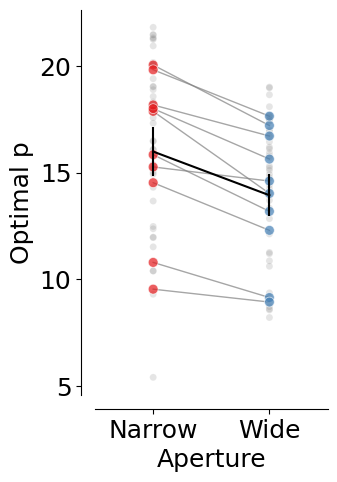

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = (
    optimal_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_ylabel("Optimal p")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Aperture")

plt.legend([], [], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")

plt.savefig(save_fig_path + "figure2_fitted_p.svg", transparent=True)

In [44]:
counts.groupby("aperture").optimal_p.mean(), counts.groupby("aperture").optimal_p.sem()

(aperture
 12.0    14.409521
 4.3     16.612429
 Name: optimal_p, dtype: float64,
 aperture
 12.0    0.489845
 4.3     0.575371
 Name: optimal_p, dtype: float64)